##**1) Load and Explore the Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("https://raw.githubusercontent.com/shanks-pony-3140/equinox101/main/week3/week3_galaxy_classification.csv")
df.head(10)



,galaxy_id,mean_brightness,galaxy_size,redshift,color_index,ellipticity,surface_brightness,concentration_index,star_formation_rate,galaxy_type
0,GLX0001,21.22,5.57,0.0388,0.481,0.113,20.07,2.33,1.64,Irregular
1,GLX0002,22.56,21.85,0.0457,0.485,0.379,18.82,2.09,0.68,Spiral
2,GLX0003,18.00,20.46,0.0706,0.894,0.539,18.72,3.46,1.60,Elliptical
3,GLX0004,18.88,8.75,0.0162,0.501,0.391,19.34,2.25,0.00,Spiral
4,GLX0005,21.52,11.34,0.0516,0.472,0.339,21.64,2.53,2.29,Spiral
5,GLX0006,25.09,5.50,0.0430,0.736,0.314,20.54,1.23,5.30,Irregular
6,GLX0007,21.12,9.90,0.0361,0.695,0.743,18.21,3.01,0.68,Elliptical
7,GLX0008,18.86,16.98,0.0793,0.923,0.718,18.27,3.33,0.97,Elliptical
8,GLX0009,21.45,3.80,0.0922,0.873,0.395,17.51,4.18,1.41,Elliptical
9,GLX0010,18.92,18.01,0.0414,0.822,0.665,19.77,3.70,0.62,Elliptical


In [ ]:
df.info()
print()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   galaxy_id            750 non-null    object 
 1   mean_brightness      750 non-null    float64
 2   galaxy_size          750 non-null    float64
 3   redshift             750 non-null    float64
 4   color_index          750 non-null    float64
 5   ellipticity          750 non-null    float64
 6   surface_brightness   750 non-null    float64
 7   concentration_index  750 non-null    float64
 8   star_formation_rate  750 non-null    float64
 9   galaxy_type          750 non-null    object 
dtypes: float64(8), object(2)
memory usage: 58.7+ KB



,mean_brightness,galaxy_size,redshift,color_index,ellipticity,surface_brightness,concentration_index,star_formation_rate
count,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000
mean,21.233267,13.642947,0.050746,0.621759,0.437055,19.790613,2.747853,2.103640
std,1.599934,5.581143,0.024584,0.231795,0.190649,1.447654,0.815030,1.636904
min,16.480000,1.000000,0.001000,-0.191000,0.000000,15.480000,1.000000,0.000000
25%,20.110000,9.445000,0.033700,0.469250,0.310000,18.745000,2.140000,0.680000
50%,21.200000,13.685000,0.049800,0.619000,0.426000,19.860000,2.685000,1.840000
75%,22.285000,17.697500,0.066400,0.803000,0.559000,20.720000,3.295000,3.330000
max,25.940000,31.620000,0.138900,1.252000,0.950000,24.550000,5.300000,7.550000


In [ ]:
df.isnull().sum()


,0
galaxy_id,0
mean_brightness,0
galaxy_size,0
redshift,0
color_index,0
ellipticity,0
surface_brightness,0
concentration_index,0
star_formation_rate,0
galaxy_type,0


In [ ]:
df["galaxy_type"].value_counts()

,count
galaxy_type,
Irregular,250
Spiral,250
Elliptical,250


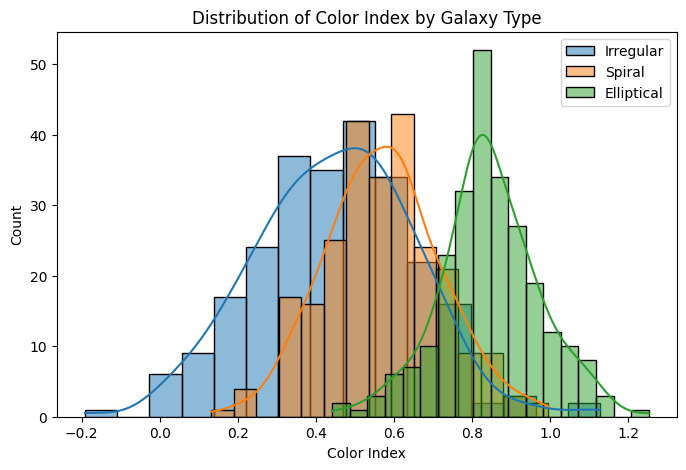

In [ ]:
plt.figure(figsize=(8,5))

for galaxy in df["galaxy_type"].unique():
    sns.histplot(df[df["galaxy_type"] == galaxy]["color_index"],label=galaxy,kde=True,alpha=0.5) #plotting hist for each type

plt.title("Distribution of Color Index by Galaxy Type")
plt.xlabel("Color Index")
plt.ylabel("Count")
plt.legend()
plt.show()

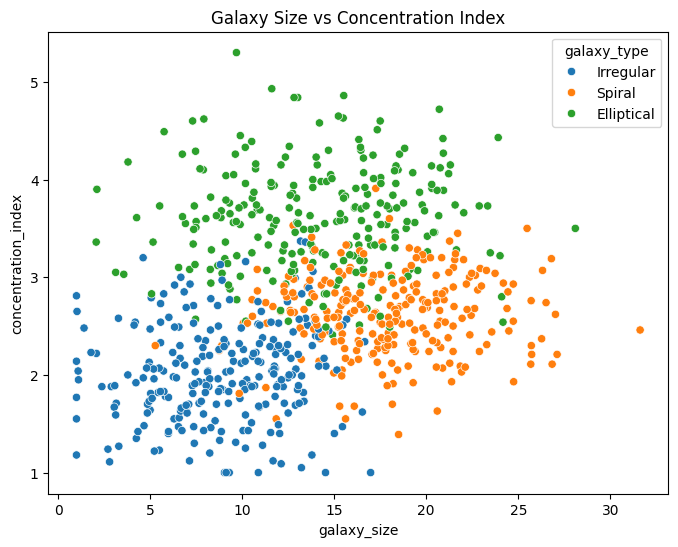

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,x="galaxy_size",y="concentration_index",hue="galaxy_type")

plt.title("Galaxy Size vs Concentration Index")
plt.show()

##**2) Prepare and Split the Data**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["galaxy_id","galaxy_type"])  #drop the columns we dont require
y = df["galaxy_type"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,stratify=y,random_state=42)# stratify to maintain proportationate representation of each class in
                                                                                               # test data
scaler=StandardScaler()                                                                      # random_state is a seed for splitting between test and training values

X_train_scaled=scaler.fit_transform(X_train) #normalising wrt training data
X_test_scaled = scaler.transform(X_test)    #normalising using statistics from training data

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (562, 8)
Testing shape: (188, 8)


##**3) Train Three Classifiers**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

#MODEL 1 - K NEAREST NEIGHBOURS

knn3 = KNeighborsClassifier(n_neighbors=3) #for 3 neighbors

knn3.fit(X_train_scaled,y_train)#training the model on normalised x and y data

y_pred_knn3 = knn3.predict(X_test_scaled) #prediction of y on scaled test data


knn7 = KNeighborsClassifier(n_neighbors=7) # for 7 neighbours

knn7.fit(X_train_scaled, y_train)  #training model on normalised x and y data

y_pred_knn7 = knn7.predict(X_test_scaled) #prediction of y on scaled test data


# MODEL 2 - GAUSSIAN NAIVE BAYES

gnb =GaussianNB()

gnb.fit(X_train_scaled,y_train)

y_pred_gnb = gnb.predict(X_test_scaled)

# MODEL 3 - SUPPORT VECTOR MACHINES

svm = SVC()

svm.fit(X_train_scaled,y_train)

y_pred_svm = svm.predict(X_test_scaled)



##**4) Evaluate the Models**


KNN (k=3)
Accuracy : 0.9202127659574468
Precision: 0.922021519538686
Recall   : 0.9202127659574468
F1 Score : 0.9206692741307997


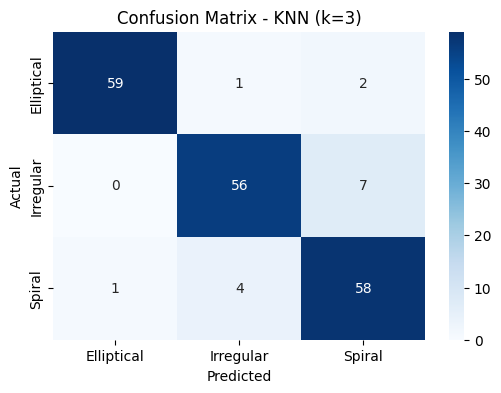


KNN (k=7)
Accuracy : 0.9361702127659575
Precision: 0.9378256303067849
Recall   : 0.9361702127659575
F1 Score : 0.936503532793102


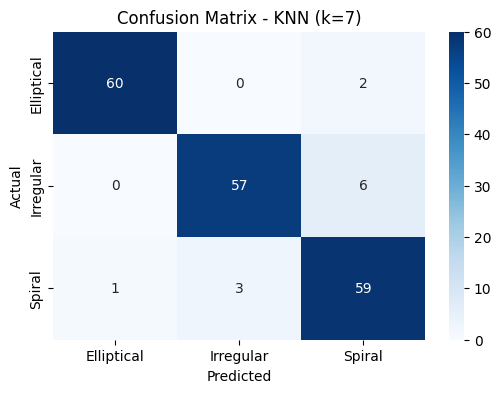


Gaussian NB
Accuracy : 0.9468085106382979
Precision: 0.9476268412438625
Recall   : 0.9468085106382979
F1 Score : 0.9470537582839205


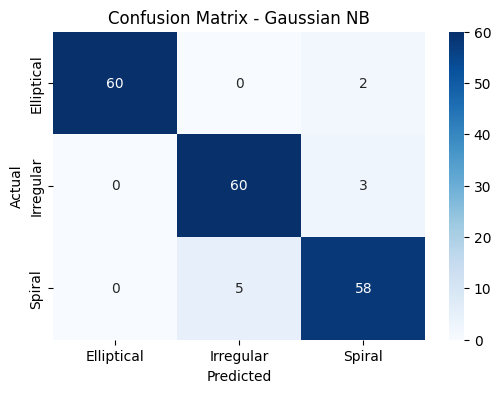


SVM
Accuracy : 0.9574468085106383
Precision: 0.958265139116203
Recall   : 0.9574468085106383
F1 Score : 0.9576920561562609


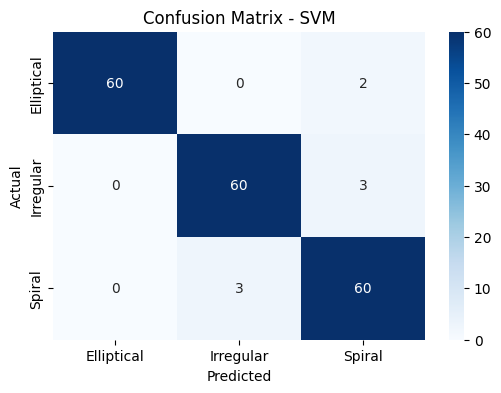

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

predictions = {
    "KNN (k=3)": y_pred_knn3,
    "KNN (k=7)": y_pred_knn7,
    "Gaussian NB": y_pred_gnb,
    "SVM": y_pred_svm
}

results = []

for model_name, y_pred in predictions.items():

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print("\n" + "="*50)
    print(model_name)
    print("="*50)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))
    labels=sorted(y_test.unique())
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [ ]:
summary_df = pd.DataFrame(results)
summary_df = summary_df.round(2)

summary_df



,Model,Accuracy,Precision,Recall,F1 Score
0,KNN (k=3),0.92,0.92,0.92,0.92
1,KNN (k=7),0.94,0.94,0.94,0.94
2,Gaussian NB,0.95,0.95,0.95,0.95
3,SVM,0.96,0.96,0.96,0.96


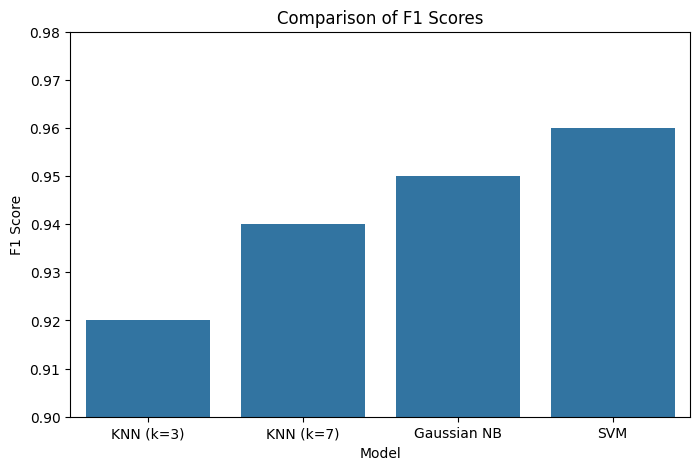

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=summary_df,
    x="Model",
    y="F1 Score"
)

plt.ylim(
    summary_df["F1 Score"].min() - 0.02,
    summary_df["F1 Score"].max() + 0.02
)

plt.title("Comparison of F1 Scores")
plt.ylabel("F1 Score")

plt.show()

The confusion matrices indicate that **Spiral** and **Irregular** galaxies are the most frequently misclassified classes across all models. A significant number of Irregular galaxies were predicted as Spiral galaxies, and similarly, several Spiral galaxies were classified as Irregular galaxies. This recurring two-way confusion suggests that these galaxy types share similar feature characteristics within the dataset, making them more difficult for the classifiers to distinguish accurately compared to Elliptical galaxies.


##**6) Conclusion**

According to the summary table, the Support Vector Machine (SVM) consistently achieved the highest Accuracy, Precision, Recall, and F1 Score among all the evaluated models. Therefore, it can be concluded that SVM performed the best for the galaxy classification task and was the most effective at distinguishing between Spiral, Elliptical, and Irregular galaxies.

However, accuracy alone is not sufficient to evaluate a classifier. For example, consider a dataset containing 95 Spiral galaxies and only 5 Irregular galaxies. A model that predicts every galaxy as Spiral would still achieve an accuracy of 95%, despite completely failing to identify any Irregular galaxies. This demonstrates that accuracy can be misleading, especially when evaluating class-wise performance. Metrics such as Precision, Recall, F1 Score, and the Confusion Matrix provide a more comprehensive assessment by revealing the types of errors made by the classifier and how well each class is being identified.